# Marketing Funnel & Conversion Performance Analysis


##  Import Libraries

In [48]:
#  Import all necessary libraries 
import pandas as pd                          # Data manipulation and analysis
import numpy as np                           # Numerical operations
import matplotlib.pyplot as plt             # Base plotting library
import matplotlib.ticker as mtick           # Percentage formatting on axes
import seaborn as sns                        # Statistical visualisations
import warnings

warnings.filterwarnings('ignore')           # Suppress minor warnings for cleaner output

# Set a consistent visual style for all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120            # Higher resolution figures
plt.rcParams['font.family'] = 'DejaVu Sans'



##  Load & Inspect the Dataset

In [17]:
#  Load the dataset 
# Replace the path below with the actual location of your CSV file
df = pd.read_csv("C:/Users/PC/Desktop/Data Sets/Funnel_Analysis_Data.csv")

# Quick sanity check: shape tells us (rows, columns)
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

# Preview the first few rows
df.head(10)

Dataset shape: 21,409 rows × 10 columns
Columns: ['User ID', 'Session ID', 'Event Time', 'Event', 'Device', 'Region', 'Channel', 'Product Category', 'Revenue', 'Bonus Flag']


,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes
5,USR-00003,SES-00003,2025-12-19 20:49:00.895328,Browse,Tablet,South,Email,Fashion,0.0,Yes
6,USR-00004,SES-00004,2026-01-08 07:58:00.840696,Browse,Tablet,East,Organic,Sports,0.0,Yes
7,USR-00004,SES-00004,2026-01-08 08:00:00.840696,Add to Cart,Tablet,East,Organic,Sports,0.0,Yes
8,USR-00004,SES-00004,2026-01-08 08:02:00.840696,Checkout,Tablet,East,Organic,Sports,0.0,Yes
9,USR-00005,SES-00005,2025-12-21 20:56:31.701462,Browse,Desktop,South,Google Ads,Beauty,0.0,Yes


In [19]:
# Data types and memory overview ──
print('=== Column Data Types ===')
print(df.dtypes)
print()

print('=== Missing Values ===')
print(df.isnull().sum())
print()

print('=== Unique Values per Column ===')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique values')

=== Column Data Types ===
User ID              object
Session ID           object
Event Time           object
Event                object
Device               object
Region               object
Channel              object
Product Category     object
Revenue             float64
Bonus Flag           object
dtype: object

=== Missing Values ===
User ID             0
Session ID          0
Event Time          0
Event               0
Device              0
Region              0
Channel             0
Product Category    0
Revenue             0
Bonus Flag          0
dtype: int64

=== Unique Values per Column ===
  User ID: 10000 unique values
  Session ID: 10000 unique values
  Event Time: 21409 unique values
  Event: 4 unique values
  Device: 3 unique values
  Region: 4 unique values
  Channel: 4 unique values
  Product Category: 5 unique values
  Revenue: 990 unique values
  Bonus Flag: 2 unique values


##  Data Cleaning & Feature Engineering

In [22]:
#   Parse the Event Time column as a proper datetime
df['Event Time'] = pd.to_datetime(df['Event Time'])

# Extract useful time-based features 
df['Date']       = df['Event Time'].dt.date          # Calendar date (for trends)
df['Hour']       = df['Event Time'].dt.hour          # Hour of day (for time-of-day analysis)
df['DayOfWeek']  = df['Event Time'].dt.day_name()   # Day name (Mon, Tue, …)
df['Week']       = df['Event Time'].dt.isocalendar().week.astype(int)  # ISO week number
df['Month']      = df['Event Time'].dt.month_name()  # Month name

# Define the correct funnel order 
# This order is critical  every metric computed depends on it.
FUNNEL_STAGES   = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']
STAGE_ORDER_MAP = {stage: i for i, stage in enumerate(FUNNEL_STAGES)}

# Add a numeric stage column for easy sorting / filtering
df['Stage_Num'] = df['Event'].map(STAGE_ORDER_MAP)

# Flag rows where Revenue > 0 as confirmed purchases 
df['Is_Purchase'] = (df['Event'] == 'Purchase').astype(int)

df[['Event Time', 'Date', 'Hour', 'DayOfWeek', 'Week', 'Event', 'Stage_Num']].head()

,Event Time,Date,Hour,DayOfWeek,Week,Event,Stage_Num
0,2026-01-07 23:46:20.358501,2026-01-07,23,Wednesday,2,Browse,0
1,2026-01-07 23:49:20.358501,2026-01-07,23,Wednesday,2,Add to Cart,1
2,2026-01-07 23:51:20.358501,2026-01-07,23,Wednesday,2,Checkout,2
3,2026-01-04 21:06:42.296010,2026-01-04,21,Sunday,1,Browse,0
4,2026-01-04 21:10:42.296010,2026-01-04,21,Sunday,1,Add to Cart,1


In [24]:
#   Build a user-level funnel table 
# For each user, we capture the HIGHEST funnel stage they reached.
# This prevents double-counting users who triggered the same event multiple times.

user_funnel = (
    df.groupby('User ID')
      .agg(
          Max_Stage      = ('Stage_Num', 'max'),   # Deepest stage reached
          Device         = ('Device',   'first'),
          Region         = ('Region',   'first'),
          Channel        = ('Channel',  'first'),
          Product_Cat    = ('Product Category', 'first'),
          Total_Revenue  = ('Revenue',  'sum'),
          Bonus_Flag     = ('Bonus Flag','first'),
      )
      .reset_index()
)

# Reverse-map the numeric stage back to a readable label
REVERSE_MAP = {v: k for k, v in STAGE_ORDER_MAP.items()}
user_funnel['Deepest_Stage'] = user_funnel['Max_Stage'].map(REVERSE_MAP)

print(f'Unique users: {len(user_funnel):,}')
user_funnel.head()

Unique users: 10,000


,User ID,Max_Stage,Device,Region,Channel,Product_Cat,Total_Revenue,Bonus_Flag,Deepest_Stage
0,USR-00001,2,Tablet,South,Organic,Electronics,0.00,Yes,Checkout
1,USR-00002,1,Desktop,East,Email,Sports,0.00,Yes,Add to Cart
2,USR-00003,0,Tablet,South,Email,Fashion,0.00,Yes,Browse
3,USR-00004,2,Tablet,East,Organic,Sports,0.00,Yes,Checkout
4,USR-00005,3,Desktop,South,Google Ads,Beauty,427.16,Yes,Purchase


## Funnel Overview – Stage Counts & Conversion Rates

In [32]:
#   Count unique users who reached each funnel stage 
# A user who reached Checkout also passed through Browse & Add to Cart,
# so we count everyone whose Max_Stage is >= the stage in question.

stage_counts = {}
for stage in FUNNEL_STAGES:
    threshold = STAGE_ORDER_MAP[stage]
    stage_counts[stage] = (user_funnel['Max_Stage'] >= threshold).sum()

funnel_df = pd.DataFrame({
    'Stage': FUNNEL_STAGES,
    'Users': [stage_counts[s] for s in FUNNEL_STAGES]
})

#  Compute conversion rates 
# Overall rate: relative to the very first stage (Browse)
top_of_funnel = funnel_df.loc[0, 'Users']
funnel_df['Overall_CR'] = (funnel_df['Users'] / top_of_funnel * 100).round(2)

# Step rate: relative to the PREVIOUS stage (sequential drop-off)
funnel_df['Step_CR'] = funnel_df['Users'].pct_change().fillna(0) * 100 + 100
funnel_df.loc[0, 'Step_CR'] = 100.0   # First stage always 100 %
funnel_df['Step_CR'] = funnel_df['Step_CR'].round(2)

# Drop-off: how many users are lost at each transition
funnel_df['Drop_Off'] = funnel_df['Users'].diff().fillna(0).abs().astype(int)
funnel_df['Drop_Off_Rate'] = (funnel_df['Drop_Off'] / top_of_funnel * 100).round(2)

print('=== Funnel Summary Table ===')
print(funnel_df.to_string(index=False))

=== Funnel Summary Table ===
      Stage  Users  Overall_CR  Step_CR  Drop_Off  Drop_Off_Rate
     Browse  10000      100.00   100.00         0           0.00
Add to Cart   6949       69.49    69.49      3051          30.51
   Checkout   3456       34.56    49.73      3493          34.93
   Purchase   1004       10.04    29.05      2452          24.52


## Visualization

FUNNEL BAR CHART

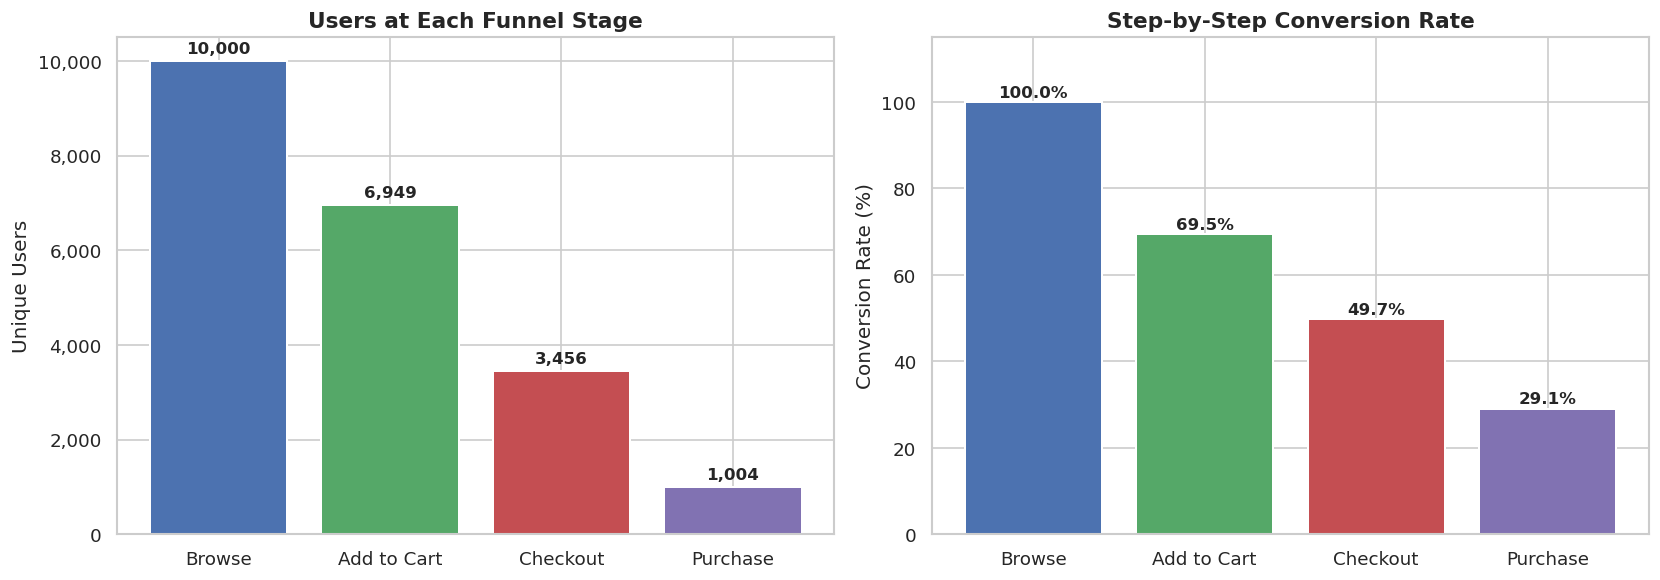

In [34]:
# Visualise the Funnel – Bar Chart 
COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']   # One colour per stage

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Side: absolute user counts per stage ---
bars = axes[0].bar(funnel_df['Stage'], funnel_df['Users'], color=COLORS, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, funnel_df['Users']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Users at Each Funnel Stage', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Unique Users')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

#  Right side: step conversion rate 
axes[1].bar(funnel_df['Stage'], funnel_df['Step_CR'], color=COLORS, edgecolor='white', linewidth=1.2)
for i, (bar, val) in enumerate(zip(axes[1].patches, funnel_df['Step_CR'])):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Step-by-Step Conversion Rate', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_ylim(0, 115)

plt.tight_layout()
plt.savefig('fig_funnel_overview.png', bbox_inches='tight')
plt.show()


FUNNEL PYRAMID CHART

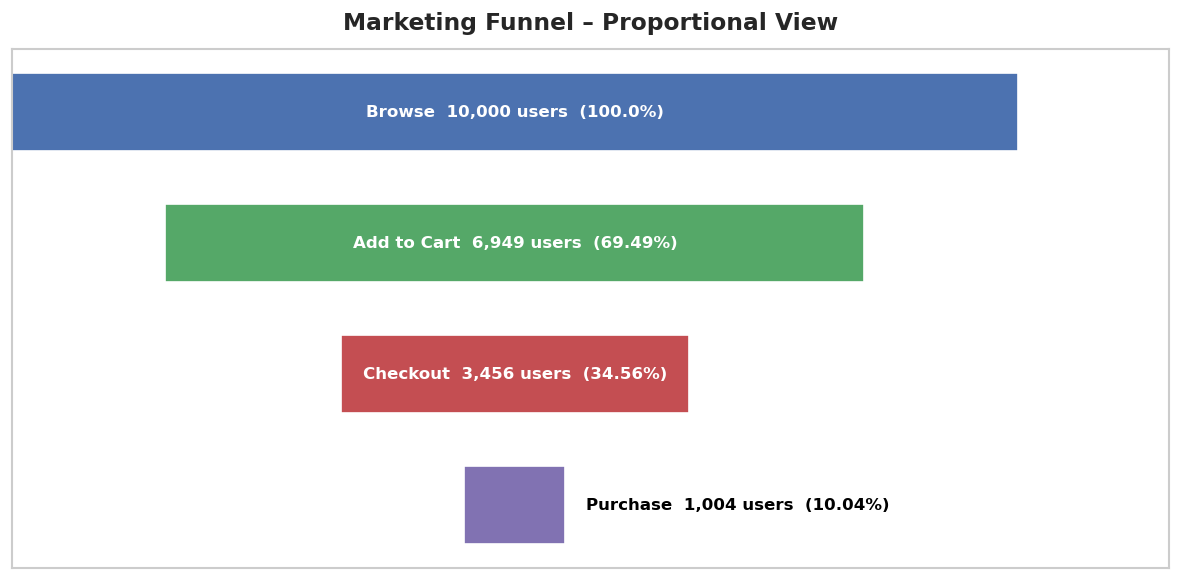

In [37]:
#   Funnel Waterfall / Pyramid Chart 
fig, ax = plt.subplots(figsize=(10, 5))

max_users = funnel_df['Users'].max()
bar_height = 0.6

for i, row in funnel_df.iterrows():
    # Normalize width
    width = row['Users'] / max_users
    
    # Draw bar (centered)
    ax.barh(i, width, height=bar_height, left=(1 - width)/2,
            color=COLORS[i], edgecolor='white')

    label = f"{row['Stage']}  {row['Users']:,} users  ({row['Overall_CR']}%)"
    
    # 🔥 FIX: Handle small bars
    if width < 0.25:
        # Place text outside (to the right)
        ax.text((1 - width)/2 + width + 0.02, i, label,
                ha='left', va='center',
                color='black', fontsize=10, fontweight='bold')
    else:
        # Place text inside
        ax.text(0.5, i, label,
                ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')

# Clean look
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 1.15)  # 🔥 extra space for outside labels
ax.set_title('Marketing Funnel – Proportional View', fontsize=14, fontweight='bold', pad=12)
ax.invert_yaxis()   # Browse at the top

plt.tight_layout()
plt.savefig('fig_funnel_pyramid.png', bbox_inches='tight')
plt.show()



##  Drop-Off Analysis

In [40]:
#  Summarise drop-off at each transition 
# We skip the first row (Browse has no preceding stage)
dropoff_df = funnel_df[funnel_df['Drop_Off'] > 0][['Stage', 'Drop_Off', 'Drop_Off_Rate']].copy()
dropoff_df['Transition'] = [
    'Browse → Add to Cart',
    'Add to Cart → Checkout',
    'Checkout → Purchase'
]

print('=== Drop-Off by Transition ===')
print(dropoff_df[['Transition', 'Drop_Off', 'Drop_Off_Rate']].to_string(index=False))

# Identify the BIGGEST drop-off point
worst = dropoff_df.loc[dropoff_df['Drop_Off'].idxmax(), 'Transition']
print(f'\n  Biggest drop-off occurs at: {worst}')

=== Drop-Off by Transition ===
            Transition  Drop_Off  Drop_Off_Rate
  Browse → Add to Cart      3051          30.51
Add to Cart → Checkout      3493          34.93
   Checkout → Purchase      2452          24.52

  Biggest drop-off occurs at: Add to Cart → Checkout


 BAR CHART OF DROP OFF RATES

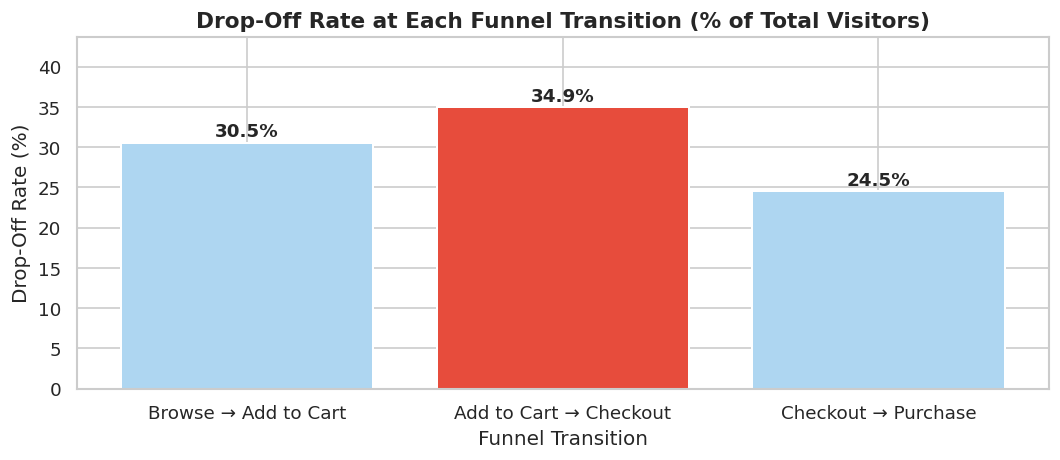

In [43]:
#  Visualise Drop-off Rates 
fig, ax = plt.subplots(figsize=(9, 4))

palette = ['#E74C3C' if v == dropoff_df['Drop_Off'].max() else '#AED6F1'
           for v in dropoff_df['Drop_Off']]

bars = ax.bar(dropoff_df['Transition'], dropoff_df['Drop_Off_Rate'],
              color=palette, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, dropoff_df['Drop_Off_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Drop-Off Rate at Each Funnel Transition (% of Total Visitors)', fontsize=13, fontweight='bold')
ax.set_ylabel('Drop-Off Rate (%)')
ax.set_xlabel('Funnel Transition')
ax.set_ylim(0, dropoff_df['Drop_Off_Rate'].max() * 1.25)

plt.tight_layout()
plt.savefig('fig_dropoff_rates.png', bbox_inches='tight')
plt.show()

##   Conversion Analysis by Marketing Channel

In [46]:
#   Purchase rate by channel 
# For each channel, we count total visitors and those who completed a purchase.

channel_df = (
    user_funnel
    .groupby('Channel')
    .agg(
        Total_Users  = ('User ID', 'count'),
        Purchasers   = ('Max_Stage', lambda x: (x == 3).sum()),  # Stage 3 = Purchase
        Total_Revenue= ('Total_Revenue', 'sum')
    )
    .reset_index()
)

channel_df['Conversion_Rate'] = (channel_df['Purchasers'] / channel_df['Total_Users'] * 100).round(2)
channel_df['Avg_Order_Value'] = (channel_df['Total_Revenue'] / channel_df['Purchasers'].replace(0, np.nan)).round(2)
channel_df = channel_df.sort_values('Conversion_Rate', ascending=False)

print('=== Channel Performance ===')
print(channel_df.to_string(index=False))

# Export for Power BI
channel_df.to_csv('channel_performance.csv', index=False)
print('\n channel_performance.csv saved')

=== Channel Performance ===
     Channel  Total_Users  Purchasers  Total_Revenue  Conversion_Rate  Avg_Order_Value
  Google Ads         2520         268       73862.32            10.63           275.61
Social Media         2437         249       68361.24            10.22           274.54
       Email         2515         248       69126.46             9.86           278.74
     Organic         2528         239       65973.04             9.45           276.04

 channel_performance.csv saved


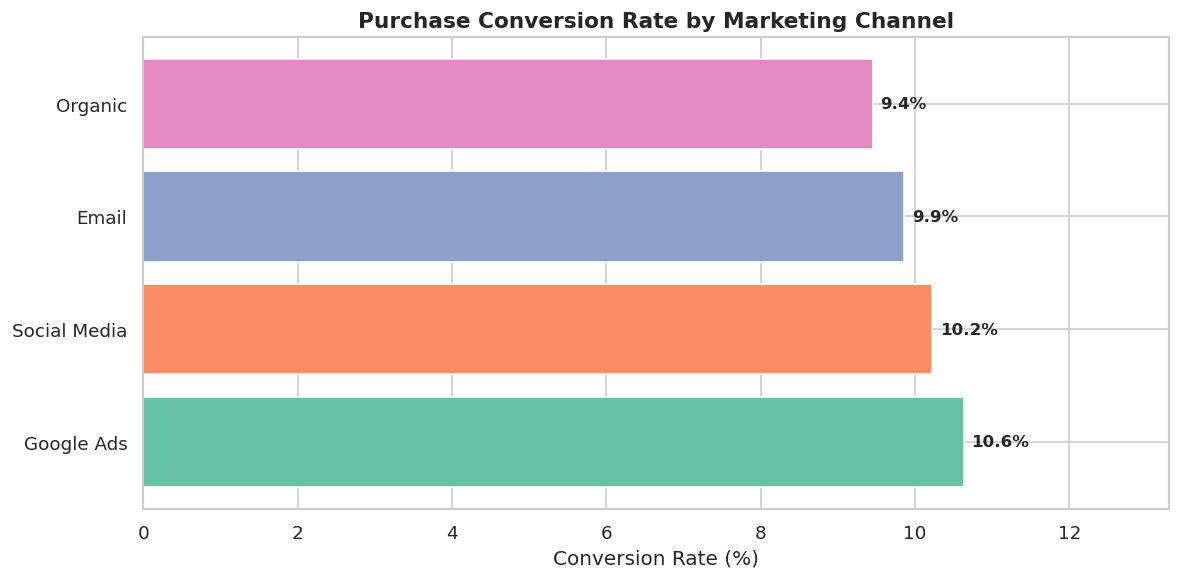

In [50]:
#  Visualise channel conversion rates 
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(channel_df['Channel'], channel_df['Conversion_Rate'],
               color=sns.color_palette('Set2', len(channel_df)),
               edgecolor='white')

for bar, val in zip(bars, channel_df['Conversion_Rate']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Purchase Conversion Rate by Marketing Channel', fontsize=13, fontweight='bold')
ax.set_xlabel('Conversion Rate (%)')
ax.set_xlim(0, channel_df['Conversion_Rate'].max() * 1.25)

plt.tight_layout()
plt.savefig('fig_channel_conversion.png', bbox_inches='tight')
plt.show()

## Device & Region Analysis

In [52]:
#  Funnel conversion by device 
def conversion_by_dimension(df_users, dimension):
    """Generic helper: purchase conversion rate grouped by any categorical column."""
    result = (
        df_users
        .groupby(dimension)
        .agg(
            Total   = ('User ID', 'count'),
            Buyers  = ('Max_Stage', lambda x: (x == 3).sum()),
            Revenue = ('Total_Revenue', 'sum')
        )
        .reset_index()
    )
    result['Conv_Rate'] = (result['Buyers'] / result['Total'] * 100).round(2)
    return result.sort_values('Conv_Rate', ascending=False)

device_df = conversion_by_dimension(user_funnel, 'Device')
region_df = conversion_by_dimension(user_funnel, 'Region')

print('=== Device Conversion ===')
print(device_df.to_string(index=False))
print('\n=== Region Conversion ===')
print(region_df.to_string(index=False))

=== Device Conversion ===
 Device  Total  Buyers  Revenue  Conv_Rate
Desktop   3366     356 98471.83      10.58
 Tablet   3371     339 94620.13      10.06
 Mobile   3263     309 84231.10       9.47

=== Region Conversion ===
Region  Total  Buyers  Revenue  Conv_Rate
 South   2543     268 77421.45      10.54
 North   2463     253 68645.13      10.27
  West   2446     238 65140.47       9.73
  East   2548     245 66116.01       9.62


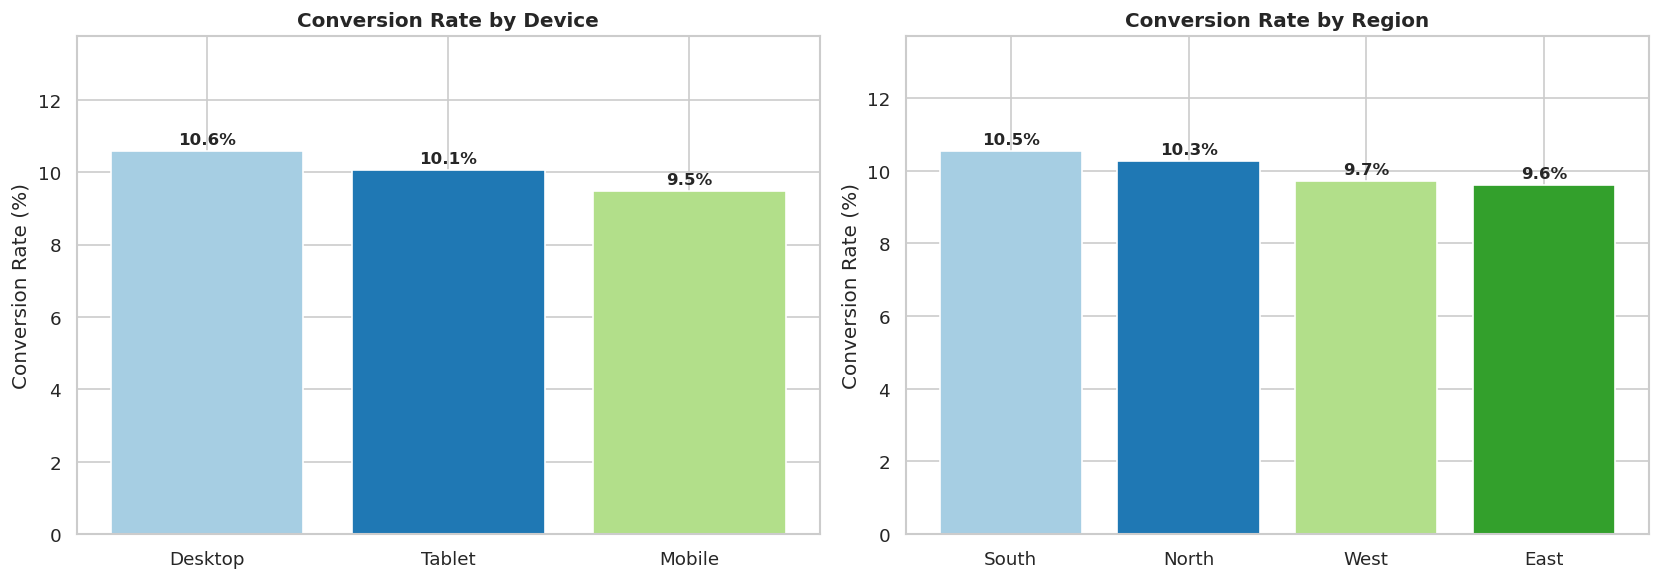

In [54]:
# Side-by-side bar charts: Device and Region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, dim, title in [
    (axes[0], device_df, 'Device', 'Conversion Rate by Device'),
    (axes[1], region_df, 'Region', 'Conversion Rate by Region')
]:
    bars = ax.bar(data[dim], data['Conv_Rate'],
                  color=sns.color_palette('Paired', len(data)), edgecolor='white')
    for bar, val in zip(bars, data['Conv_Rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_ylim(0, data['Conv_Rate'].max() * 1.3)

plt.tight_layout()
plt.savefig('fig_device_region.png', bbox_inches='tight')
plt.show()

##  Product Category Analysis

In [56]:
# Conversion and revenue by product category 
category_df = (
    user_funnel
    .groupby('Product_Cat')
    .agg(
        Total_Users  = ('User ID', 'count'),
        Purchasers   = ('Max_Stage', lambda x: (x == 3).sum()),
        Total_Revenue= ('Total_Revenue', 'sum')
    )
    .reset_index()
)

category_df['Conv_Rate']       = (category_df['Purchasers'] / category_df['Total_Users'] * 100).round(2)
category_df['Avg_Order_Value'] = (category_df['Total_Revenue'] / category_df['Purchasers'].replace(0, np.nan)).round(2)
category_df['Revenue_Share']   = (category_df['Total_Revenue'] / category_df['Total_Revenue'].sum() * 100).round(2)
category_df = category_df.sort_values('Total_Revenue', ascending=False)

print('=== Product Category Performance ===')
print(category_df.to_string(index=False))
category_df.to_csv('category_performance.csv', index=False)
print('\n category_performance.csv saved')

=== Product Category Performance ===
Product_Cat  Total_Users  Purchasers  Total_Revenue  Conv_Rate  Avg_Order_Value  Revenue_Share
Electronics         2052         229       62938.46      11.16           274.84          22.69
    Fashion         2001         211       58075.22      10.54           275.24          20.94
     Sports         1948         189       55856.01       9.70           295.53          20.14
     Beauty         2021         191       50353.36       9.45           263.63          18.16
       Home         1978         184       50100.01       9.30           272.28          18.07

 category_performance.csv saved


BUBBLE CHART OF REVENUE VS CONVERSION RATE

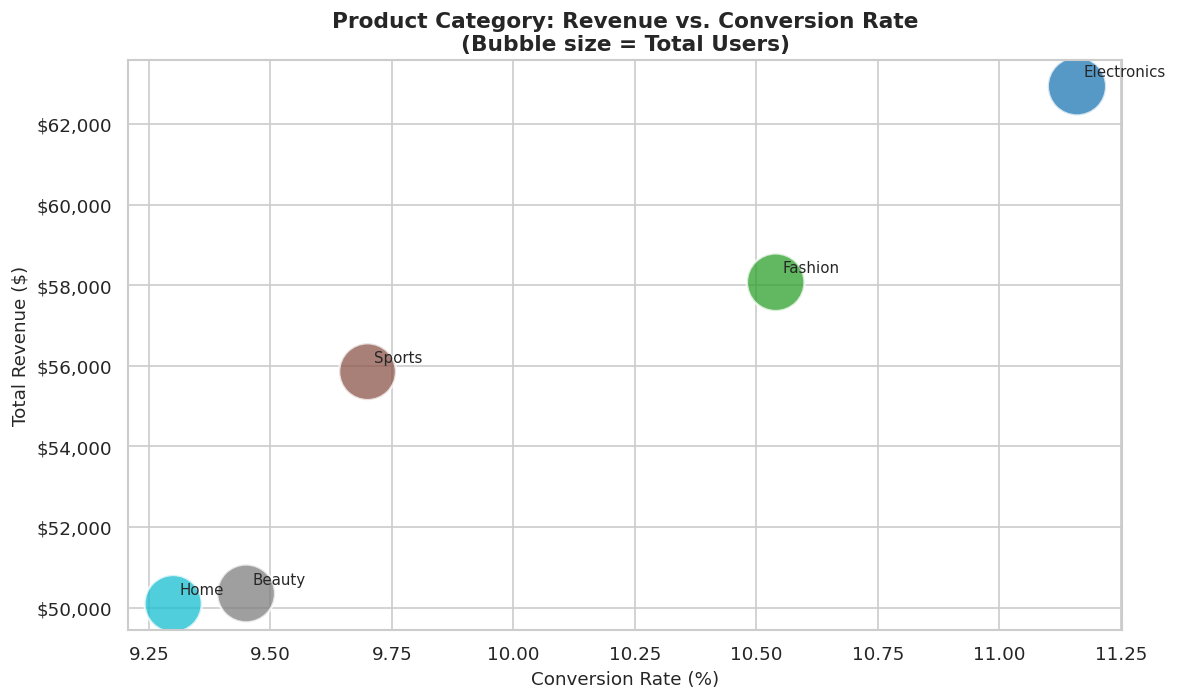

In [58]:
# Bubble chart: Revenue vs. Conversion Rate  
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    category_df['Conv_Rate'],
    category_df['Total_Revenue'],
    s=category_df['Total_Users'] * 0.6,   # Bubble size proportional to user count
    c=range(len(category_df)),
    cmap='tab10',
    alpha=0.75,
    edgecolors='white',
    linewidths=1.5
)

# Label each bubble
for _, row in category_df.iterrows():
    ax.annotate(row['Product_Cat'],
                (row['Conv_Rate'], row['Total_Revenue']),
                fontsize=9, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Conversion Rate (%)', fontsize=11)
ax.set_ylabel('Total Revenue ($)', fontsize=11)
ax.set_title('Product Category: Revenue vs. Conversion Rate\n(Bubble size = Total Users)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('fig_category_bubble.png', bbox_inches='tight')
plt.show()

## Time-Based Trends

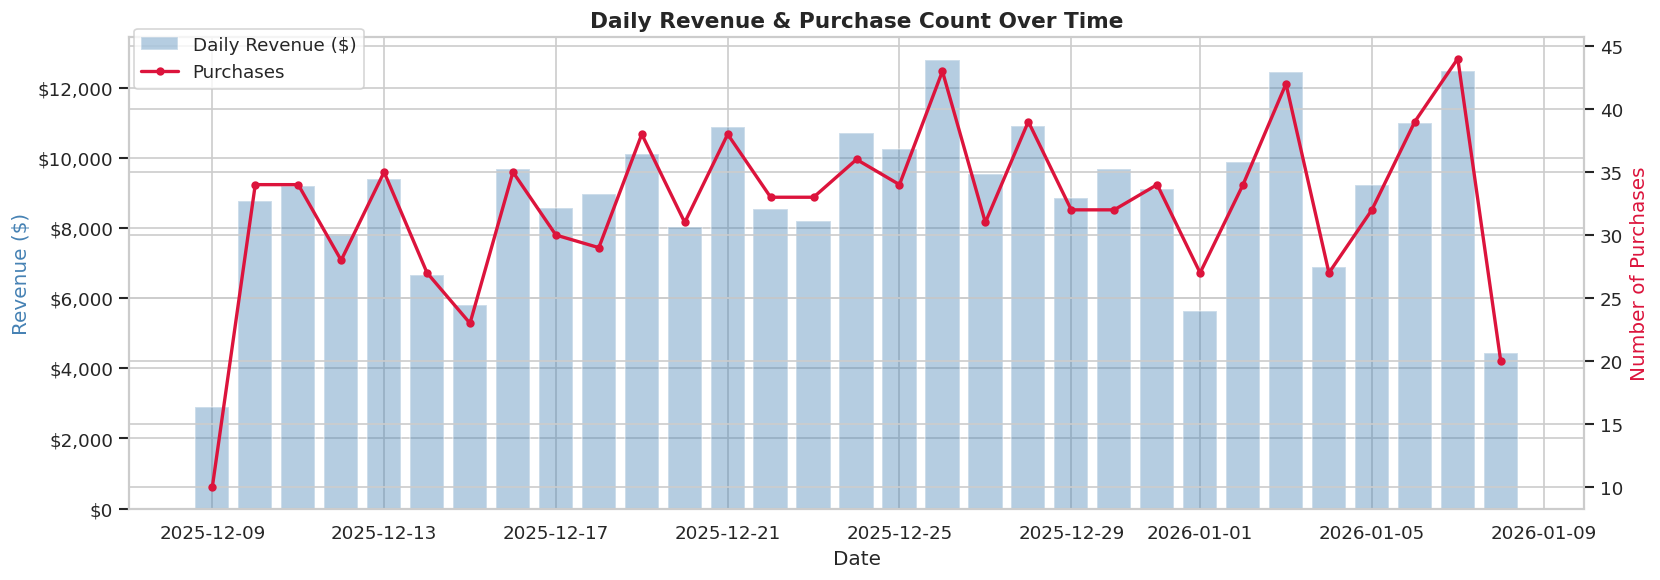

In [60]:
# Daily purchase count trend
daily_purchases = (
    df[df['Event'] == 'Purchase']
    .groupby('Date')
    .agg(Purchases=('User ID', 'count'), Revenue=('Revenue', 'sum'))
    .reset_index()
)

daily_purchases['Date'] = pd.to_datetime(daily_purchases['Date'])

fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart for daily revenue
ax1.bar(daily_purchases['Date'], daily_purchases['Revenue'], alpha=0.4,
        color='steelblue', label='Daily Revenue ($)')
ax1.set_ylabel('Revenue ($)', color='steelblue')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Line chart for purchase count on a second y-axis
ax2 = ax1.twinx()
ax2.plot(daily_purchases['Date'], daily_purchases['Purchases'],
         color='crimson', linewidth=2, marker='o', markersize=4, label='Purchases')
ax2.set_ylabel('Number of Purchases', color='crimson')

ax1.set_title('Daily Revenue & Purchase Count Over Time', fontsize=13, fontweight='bold')
ax1.set_xlabel('Date')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.95))

plt.tight_layout()
plt.savefig('fig_daily_trend.png', bbox_inches='tight')
plt.show()

HEATMAP OF DAILY PURCHASE ACTIVITY WITH TIME

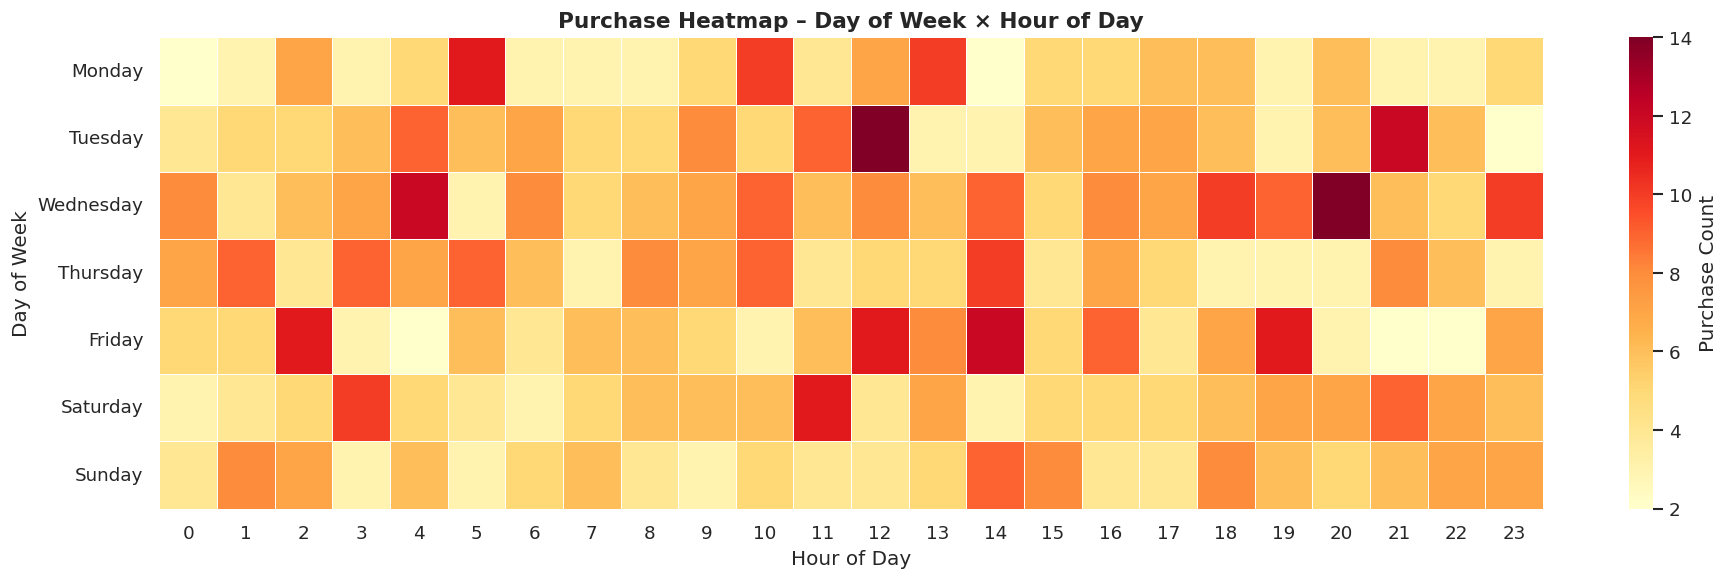

In [62]:
# Hourly activity heatmap (day-of-week × hour) 
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (
    df[df['Event'] == 'Purchase']
    .groupby(['DayOfWeek', 'Hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(DOW_ORDER)          # Force correct weekday order
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Purchase Count'})
ax.set_title('Purchase Heatmap – Day of Week × Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight')
plt.show()

##   Revenue Analysis

In [64]:
#  Key revenue KPIs 
purchase_events = df[df['Event'] == 'Purchase']

total_revenue   = purchase_events['Revenue'].sum()
total_purchases = len(purchase_events)
avg_order_value = purchase_events['Revenue'].mean()
median_order    = purchase_events['Revenue'].median()
top_10_pct      = purchase_events['Revenue'].quantile(0.90)

print('=== Revenue KPIs ===')
print(f'  Total Revenue      : ${total_revenue:>12,.2f}')
print(f'  Total Purchases    : {total_purchases:>12,}')
print(f'  Avg. Order Value   : ${avg_order_value:>12,.2f}')
print(f'  Median Order Value : ${median_order:>12,.2f}')
print(f'  90th Percentile    : ${top_10_pct:>12,.2f}')

=== Revenue KPIs ===
  Total Revenue      : $  277,323.06
  Total Purchases    :        1,004
  Avg. Order Value   : $      276.22
  Median Order Value : $      278.07
  90th Percentile    : $      458.70


REVENUE DISTRIBUTION HISTOGRAM

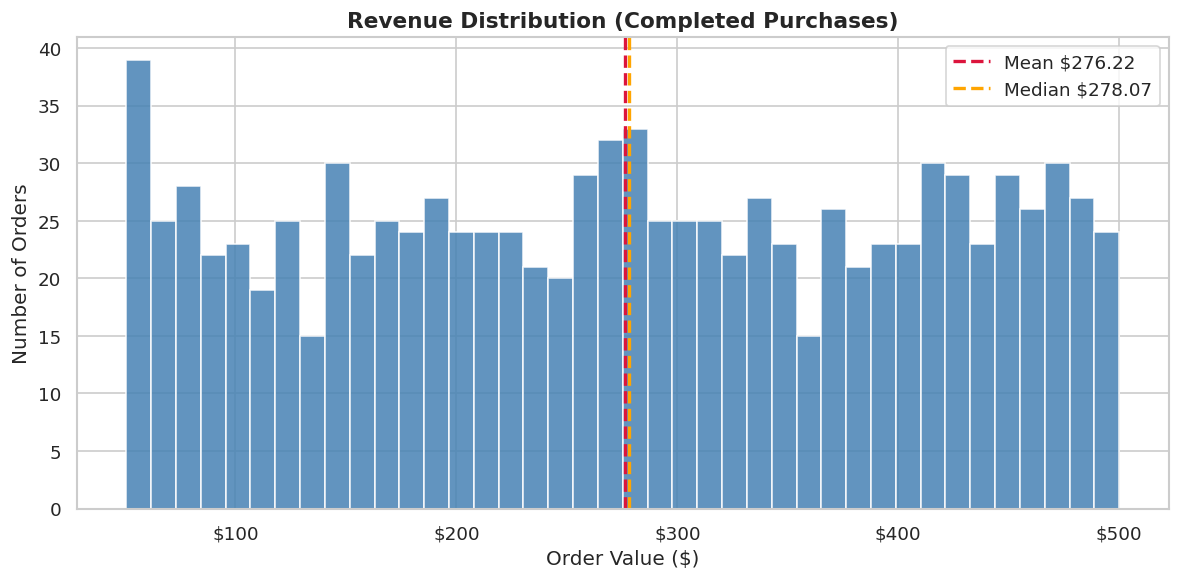

In [66]:
# Revenue distribution histogram 
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(purchase_events['Revenue'], bins=40, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(avg_order_value, color='crimson', linestyle='--', linewidth=2,
           label=f'Mean ${avg_order_value:,.2f}')
ax.axvline(median_order, color='orange', linestyle='--', linewidth=2,
           label=f'Median ${median_order:,.2f}')

ax.set_title('Revenue Distribution (Completed Purchases)', fontsize=13, fontweight='bold')
ax.set_xlabel('Order Value ($)')
ax.set_ylabel('Number of Orders')
ax.legend()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('fig_revenue_distribution.png', bbox_inches='tight')
plt.show()

PIE CHART OF REVENUE BY CHANNEL

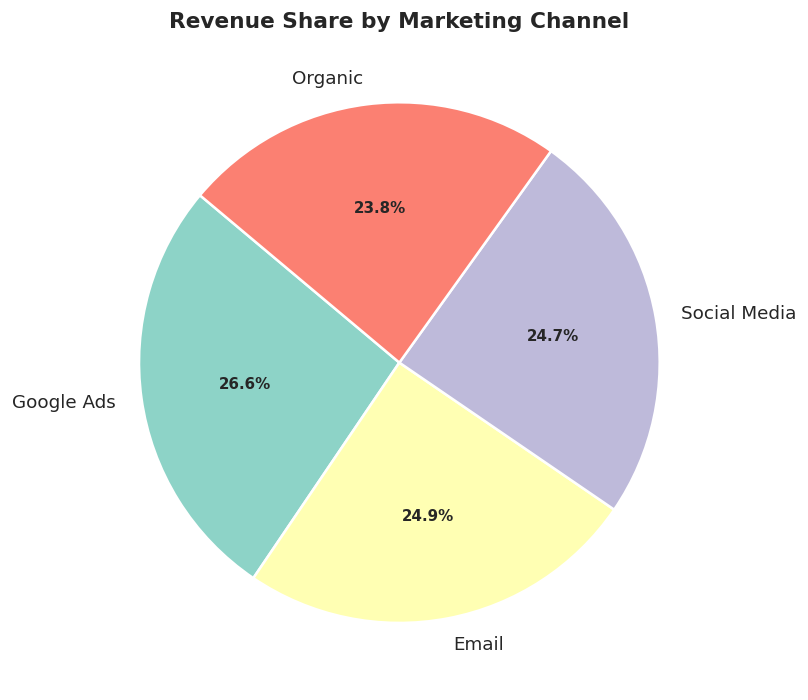

In [68]:
#   Revenue by Channel 
rev_by_channel = purchase_events.groupby('Channel')['Revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    rev_by_channel,
    labels=rev_by_channel.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set3', len(rev_by_channel)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title('Revenue Share by Marketing Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_revenue_by_channel.png', bbox_inches='tight')
plt.show()

##  Key Findings & Recommendations

In [70]:

browse_to_cart_cr   = funnel_df.loc[1, 'Step_CR']
cart_to_checkout_cr = funnel_df.loc[2, 'Step_CR']
checkout_to_pur_cr  = funnel_df.loc[3, 'Step_CR']
overall_cr          = funnel_df.loc[3, 'Overall_CR']

best_channel  = channel_df.iloc[0]['Channel']
best_chan_cr  = channel_df.iloc[0]['Conversion_Rate']
worst_channel = channel_df.iloc[-1]['Channel']
worst_chan_cr = channel_df.iloc[-1]['Conversion_Rate']

best_device   = device_df.iloc[0]['Device']
best_dev_cr   = device_df.iloc[0]['Conv_Rate']

print('=' * 60)
print('        MARKETING FUNNEL – KEY FINDINGS')
print('=' * 60)
print(f"""
 FUNNEL OVERVIEW
  • Overall (Browse → Purchase) conversion rate : {overall_cr:.2f}%
  • Browse → Add to Cart conversion             : {browse_to_cart_cr:.2f}%
  • Add to Cart → Checkout conversion           : {cart_to_checkout_cr:.2f}%
  • Checkout → Purchase conversion              : {checkout_to_pur_cr:.2f}%

 BIGGEST DROP-OFF
  • {worst} 

 CHANNEL PERFORMANCE
  • Best channel  : {best_channel}  ({best_chan_cr:.1f}% conversion)
  • Worst channel : {worst_channel}  ({worst_chan_cr:.1f}% conversion)

 DEVICE PERFORMANCE
  • Highest converting device: {best_device} ({best_dev_cr:.1f}%)

 REVENUE
  • Total Revenue       : ${total_revenue:>10,.2f}
  • Avg. Order Value    : ${avg_order_value:>10,.2f}
""")

print('=' * 60)
print('        RECOMMENDATIONS')
print('=' * 60)
print("""
1. REDUCE BROWSE → ADD TO CART DROP-OFF
   → Improve product page CTAs, add social proof (reviews/ratings),
     use personalised recommendations to increase intent.

2. RECOVER ABANDONED CARTS (Add to Cart → Checkout)
   → Implement cart-abandonment email sequences within 1h of abandonment.
     Offer limited-time discount codes to incentivise return.

3. STREAMLINE CHECKOUT (Checkout → Purchase)
   → Reduce form fields, offer guest checkout, and display
     trust signals (SSL badge, free returns) prominently.

4. INVEST MORE IN TOP-PERFORMING CHANNELS
   → Allocate more budget to the channels with the highest
     conversion rates and AOV; pause or restructure low performers.

5. OPTIMISE FOR THE BEST-CONVERTING DEVICE
   → Conduct UX audits on under-performing device types;
     A/B test layouts specifically for mobile vs. desktop.

6. FOCUS ON HIGH-REVENUE PRODUCT CATEGORIES
   → Feature top-revenue categories in landing pages and ads.
     Cross-sell complementary products at checkout.

7. TIME-BASED PROMOTIONS
   → Use the heatmap  to schedule flash sales or
     push notifications during peak purchase hours/days.
""")

        MARKETING FUNNEL – KEY FINDINGS

 FUNNEL OVERVIEW
  • Overall (Browse → Purchase) conversion rate : 10.04%
  • Browse → Add to Cart conversion             : 69.49%
  • Add to Cart → Checkout conversion           : 49.73%
  • Checkout → Purchase conversion              : 29.05%

 BIGGEST DROP-OFF
  • Add to Cart → Checkout 

 CHANNEL PERFORMANCE
  • Best channel  : Google Ads  (10.6% conversion)
  • Worst channel : Organic  (9.4% conversion)

 DEVICE PERFORMANCE
  • Highest converting device: Desktop (10.6%)

 REVENUE
  • Total Revenue       : $277,323.06
  • Avg. Order Value    : $    276.22

        RECOMMENDATIONS

1. REDUCE BROWSE → ADD TO CART DROP-OFF
   → Improve product page CTAs, add social proof (reviews/ratings),
     use personalised recommendations to increase intent.

2. RECOVER ABANDONED CARTS (Add to Cart → Checkout)
   → Implement cart-abandonment email sequences within 1h of abandonment.
     Offer limited-time discount codes to incentivise return.

3. STREAMLI